## Questão 3 – Regressão

**Enunciado:**  
Faça um código em Python para construir um problema de Regressão a partir da base escolhida, seja utilizando o alvo original quando ele for numérico, seja definindo uma variável quantitativa derivada coerente com o cenário. Implemente pelo menos dois modelos de regressão, compare desempenho com métricas adequadas e analise os resíduos, discutindo se há sinais de não linearidade, heterocedasticidade ou influência excessiva de outliers.

### Raciocínio

Como a base Telco não possui uma variável numérica alvo originalmente definida, foi necessário construir um subproblema de regressão que fosse coerente tanto do ponto de vista estatístico quanto do ponto de vista de negócio. Os resultados da Questão 2 mostraram que `MonthlyCharges`, `TotalCharges` e `tenure` possuem forte relação entre si, especialmente porque o valor total gasto pelo cliente é naturalmente influenciado pelo tempo de permanência e pela cobrança mensal do plano contratado.

A partir disso, o problema escolhido foi prever `TotalCharges` utilizando informações do perfil do cliente, serviços contratados e duração do contrato. Essa escolha é relevante porque permite estimar o valor acumulado de um cliente ao longo do relacionamento com a empresa, funcionando como uma aproximação prática de LTV (*Lifetime Value*). Em um cenário real, isso ajuda equipes de retenção e marketing a identificar quais clientes possuem maior valor potencial e, portanto, merecem maior prioridade em campanhas de retenção.

Para avaliar esse problema, foram comparados dois modelos diferentes. O primeiro foi uma Regressão Linear Múltipla tradicional, utilizada como linha de base por ser simples, interpretável e diretamente relacionada ao conteúdo estudado em sala. O segundo modelo adiciona um termo de interação entre `tenure` e `MonthlyCharges`, buscando representar explicitamente a relação multiplicativa já identificada anteriormente nos dados.

Além do desempenho numérico, a análise também considerou o comportamento dos resíduos. Essa etapa é importante porque permite verificar se as hipóteses básicas da regressão linear continuam válidas. Foram analisados sinais de heterocedasticidade, possíveis padrões de não linearidade e presença de outliers influentes, já que esses fatores podem indicar limitações do modelo mesmo quando as métricas globais parecem boas.

As métricas escolhidas foram MAE, RMSE e R². O R² permite medir quanto da variabilidade de `TotalCharges` é explicada pelo modelo, enquanto MAE e RMSE tornam o erro mais interpretável no contexto financeiro, mostrando aproximadamente quanto o modelo erra em reais ao estimar o valor acumulado de um cliente.


### Desenvolvimento

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

In [3]:
# ── Pré-processamento herdado das questões anteriores ────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

# Corrige tipagem e imputa TotalCharges (estratégia vencedora da Lista 1, Q3)
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask_missing = df['TotalCharges'].isna()
df.loc[mask_missing, 'TotalCharges'] = (
    df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure']
)

# Remove identificador
df.drop(columns=['customerID'], inplace=True)

# Padroniza categorias de serviço
SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print(f'Base pronta: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Ausentes restantes: {df.isna().sum().sum()}')

Base pronta: 7043 linhas × 20 colunas
Ausentes restantes: 0


In [4]:
# ── Definição do subproblema de regressão ─────────────────────────────────────
# Alvo: TotalCharges (valor total gasto pelo cliente)
# Features: tudo exceto TotalCharges e Churn (o alvo de classificação)

TARGET_REG = 'TotalCharges'
EXCLUDE    = ['TotalCharges', 'Churn']

X = df.drop(columns=EXCLUDE)
y = df[TARGET_REG]

NUM_COLS = ['tenure', 'MonthlyCharges']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

print(f'Alvo: {TARGET_REG}')
print(f'  Média: R$ {y.mean():.2f} | Mediana: R$ {y.median():.2f} | Desvio: R$ {y.std():.2f}')
print(f'  Mín: R$ {y.min():.2f} | Máx: R$ {y.max():.2f}')
print(f'\nFeatures numéricas ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Features categóricas ({len(CAT_COLS)}): {CAT_COLS}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')

Alvo: TotalCharges
  Média: R$ 2279.73 | Mediana: R$ 1394.55 | Desvio: R$ 2266.79
  Mín: R$ 0.00 | Máx: R$ 8684.80

Features numéricas (2): ['tenure', 'MonthlyCharges']
Features categóricas (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Treino: 5634 | Teste: 1409


In [5]:
# ── Função de avaliação ───────────────────────────────────────────────────────
def evaluate_regression(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    residuals = y_te.values - y_pred

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    return {
        'modelo'    : model_name,
        'MAE'       : round(mae, 2),
        'RMSE'      : round(rmse, 2),
        'R2'        : round(r2, 4),
        'y_pred'    : y_pred,
        'residuals' : residuals,
        'pipeline'  : pipeline
    }


def cv_regression(pipeline, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        pipeline, X, y, cv=kf,
        scoring=['r2', 'neg_mean_absolute_error'],
        return_train_score=False
    )
    return {
        'R2_cv_mean' : round(scores['test_r2'].mean(), 4),
        'R2_cv_std'  : round(scores['test_r2'].std(), 4),
        'MAE_cv_mean': round(-scores['test_neg_mean_absolute_error'].mean(), 2),
    }

In [6]:
# ── Modelo 1: Regressão Linear Múltipla (baseline) ────────────────────────────
# OHE nas categóricas + StandardScaler nas numéricas
# Modelo direto da aula 11: Y = β0 + β1·X1 + β2·X2 + ... + ε

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_linear = Pipeline([
    ('prep', preprocessor),
    ('reg' , LinearRegression())
])

res_linear = evaluate_regression(pipe_linear, X_train, y_train, X_test, y_test, 'Linear Múltipla')
cv_linear  = cv_regression(pipe_linear, X, y)

print('Modelo 1 — Regressão Linear Múltipla')
print(f'  MAE  : R$ {res_linear["MAE"]:.2f}')
print(f'  RMSE : R$ {res_linear["RMSE"]:.2f}')
print(f'  R²   : {res_linear["R2"]}')
print(f'  R² CV (5-fold): {cv_linear["R2_cv_mean"]} ± {cv_linear["R2_cv_std"]}')
print(f'  MAE CV (5-fold): R$ {cv_linear["MAE_cv_mean"]}')

Modelo 1 — Regressão Linear Múltipla
  MAE  : R$ 569.42
  RMSE : R$ 703.17
  R²   : 0.905
  R² CV (5-fold): 0.9067 ± 0.0023
  MAE CV (5-fold): R$ 558.51


In [7]:
# ── Modelo 2: Regressão com Interação tenure × MonthlyCharges ─────────────────
# A Q2 mostrou que TotalCharges ≈ MonthlyCharges × tenure estruturalmente.
# Adicionar esse produto como feature explicita essa relação ao modelo linear,
# que por si só não captura interações multiplicativas.

X_inter_train = X_train.copy()
X_inter_test  = X_test.copy()

X_inter_train['tenure_x_monthly'] = X_inter_train['tenure'] * X_inter_train['MonthlyCharges']
X_inter_test['tenure_x_monthly']  = X_inter_test['tenure']  * X_inter_test['MonthlyCharges']

NUM_COLS_INTER = NUM_COLS + ['tenure_x_monthly']

preprocessor_inter = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS_INTER),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_inter = Pipeline([
    ('prep', preprocessor_inter),
    ('reg' , LinearRegression())
])

res_inter = evaluate_regression(pipe_inter, X_inter_train, y_train, X_inter_test, y_test, 'Linear + Interação')

# CV para o modelo com interação (aplica transformação antes do CV)
X_inter_full = X.copy()
X_inter_full['tenure_x_monthly'] = X_inter_full['tenure'] * X_inter_full['MonthlyCharges']
cv_inter = cv_regression(pipe_inter, X_inter_full, y)

print('Modelo 2 — Regressão Linear + Interação tenure×MonthlyCharges')
print(f'  MAE  : R$ {res_inter["MAE"]:.2f}')
print(f'  RMSE : R$ {res_inter["RMSE"]:.2f}')
print(f'  R²   : {res_inter["R2"]}')
print(f'  R² CV (5-fold): {cv_inter["R2_cv_mean"]} ± {cv_inter["R2_cv_std"]}')
print(f'  MAE CV (5-fold): R$ {cv_inter["MAE_cv_mean"]}')

Modelo 2 — Regressão Linear + Interação tenure×MonthlyCharges
  MAE  : R$ 45.63
  RMSE : R$ 68.23
  R²   : 0.9991
  R² CV (5-fold): 0.9991 ± 0.0001
  MAE CV (5-fold): R$ 45.47


In [8]:
# ── Tabela comparativa consolidada ────────────────────────────────────────────
rows = []
for res, cv in [(res_linear, cv_linear), (res_inter, cv_inter)]:
    rows.append({
        'Modelo'         : res['modelo'],
        'MAE (teste)'    : f"R$ {res['MAE']:.2f}",
        'RMSE (teste)'   : f"R$ {res['RMSE']:.2f}",
        'R² (teste)'     : res['R2'],
        'R² CV (média)'  : cv['R2_cv_mean'],
        'R² CV (dp)'     : cv['R2_cv_std'],
        'MAE CV (média)' : f"R$ {cv['MAE_cv_mean']:.2f}",
    })

df_comp = pd.DataFrame(rows)
print('=== Comparação dos modelos de regressão ===')
display(df_comp)

=== Comparação dos modelos de regressão ===


,Modelo,MAE (teste),RMSE (teste),R² (teste),R² CV (média),R² CV (dp),MAE CV (média)
0,Linear Múltipla,R$ 569.42,R$ 703.17,0.9050,0.9067,0.0023,R$ 558.51
1,Linear + Interação,R$ 45.63,R$ 68.23,0.9991,0.9991,0.0001,R$ 45.47


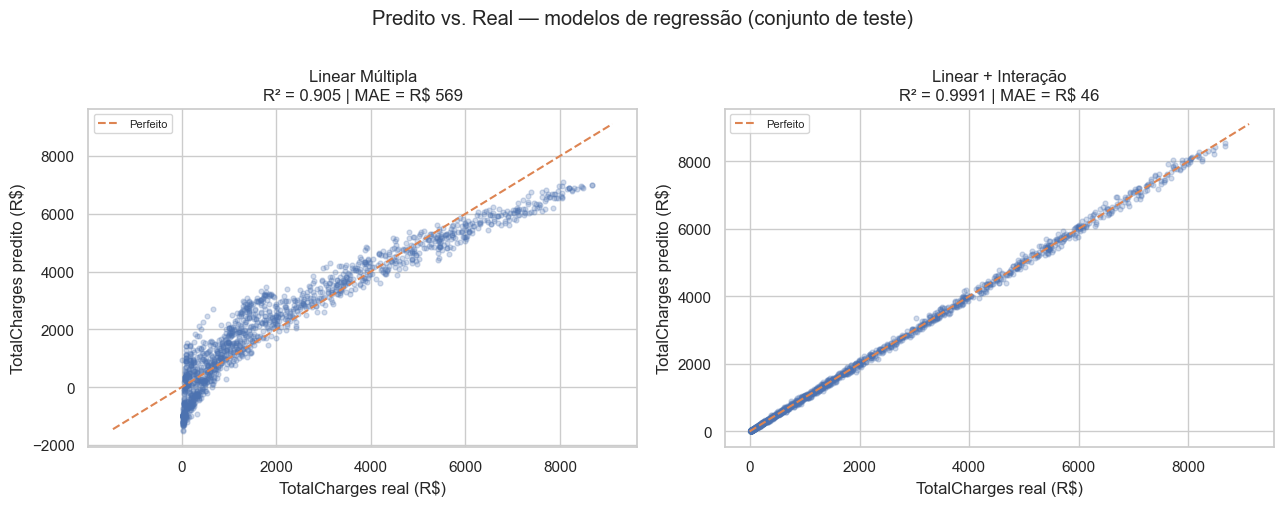

In [9]:
# ── Gráfico 1: Predito vs. Real (ambos os modelos) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res in zip(axes, [res_linear, res_inter]):
    ax.scatter(y_test, res['y_pred'], alpha=0.25, s=12, color='#4C72B0')
    lim_min = min(y_test.min(), res['y_pred'].min()) * 0.95
    lim_max = max(y_test.max(), res['y_pred'].max()) * 1.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='#DD8452', linewidth=1.5, linestyle='--', label='Perfeito')
    ax.set_xlabel('TotalCharges real (R$)')
    ax.set_ylabel('TotalCharges predito (R$)')
    ax.set_title(f"{res['modelo']}\nR² = {res['R2']} | MAE = R$ {res['MAE']:.0f}")
    ax.legend(fontsize=8)

plt.suptitle('Predito vs. Real — modelos de regressão (conjunto de teste)', y=1.01)
plt.tight_layout()
plt.show()

Linear Múltipla — resíduos:
  Média   : -10.49
  Desvio  : 703.09
  Outliers (IQR): 1 (0.1%)
Linear + Interação — resíduos:
  Média   : -2.90
  Desvio  : 68.17
  Outliers (IQR): 125 (8.9%)


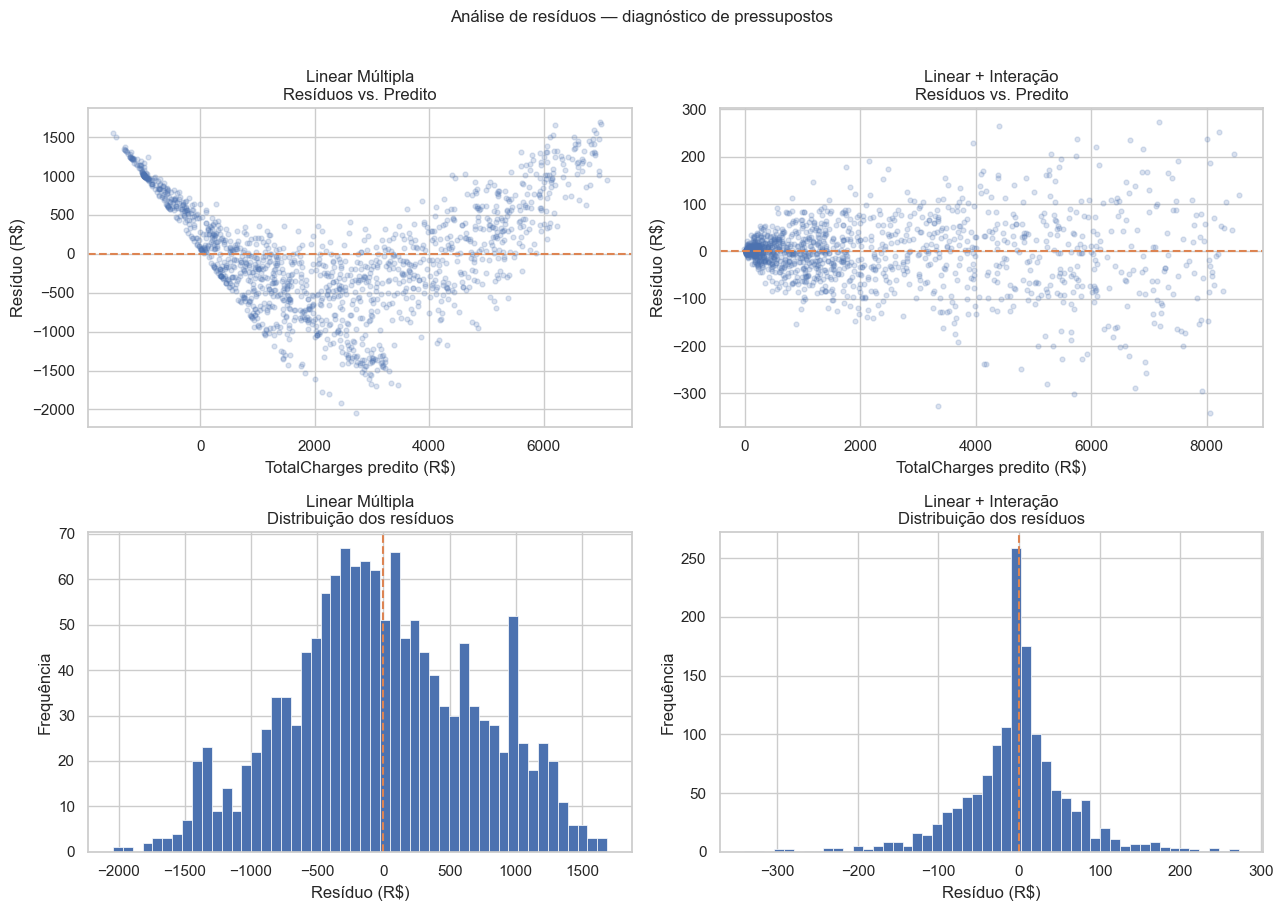

In [10]:
# ── Gráfico 2: Análise de resíduos ────────────────────────────────────────────
# Para cada modelo: resíduos vs. predito (detecta heterocedasticidade)
# e histograma de resíduos (detecta não normalidade / outliers)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, res in enumerate([res_linear, res_inter]):
    resid = res['residuals']
    y_hat = res['y_pred']

    # Resíduos vs. Predito
    ax = axes[0, col]
    ax.scatter(y_hat, resid, alpha=0.2, s=12, color='#4C72B0')
    ax.axhline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('TotalCharges predito (R$)')
    ax.set_ylabel('Resíduo (R$)')
    ax.set_title(f'{res["modelo"]}\nResíduos vs. Predito')

    # Histograma dos resíduos
    ax = axes[1, col]
    ax.hist(resid, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Resíduo (R$)')
    ax.set_ylabel('Frequência')
    ax.set_title(f'{res["modelo"]}\nDistribuição dos resíduos')

    # Estatísticas de resíduo
    q1, q3 = np.percentile(resid, [25, 75])
    outliers = np.sum((resid < q1 - 1.5*(q3-q1)) | (resid > q3 + 1.5*(q3-q1)))
    print(f'{res["modelo"]} — resíduos:')
    print(f'  Média   : {resid.mean():.2f}')
    print(f'  Desvio  : {resid.std():.2f}')
    print(f'  Outliers (IQR): {outliers} ({outliers/len(resid)*100:.1f}%)')

plt.suptitle('Análise de resíduos — diagnóstico de pressupostos', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

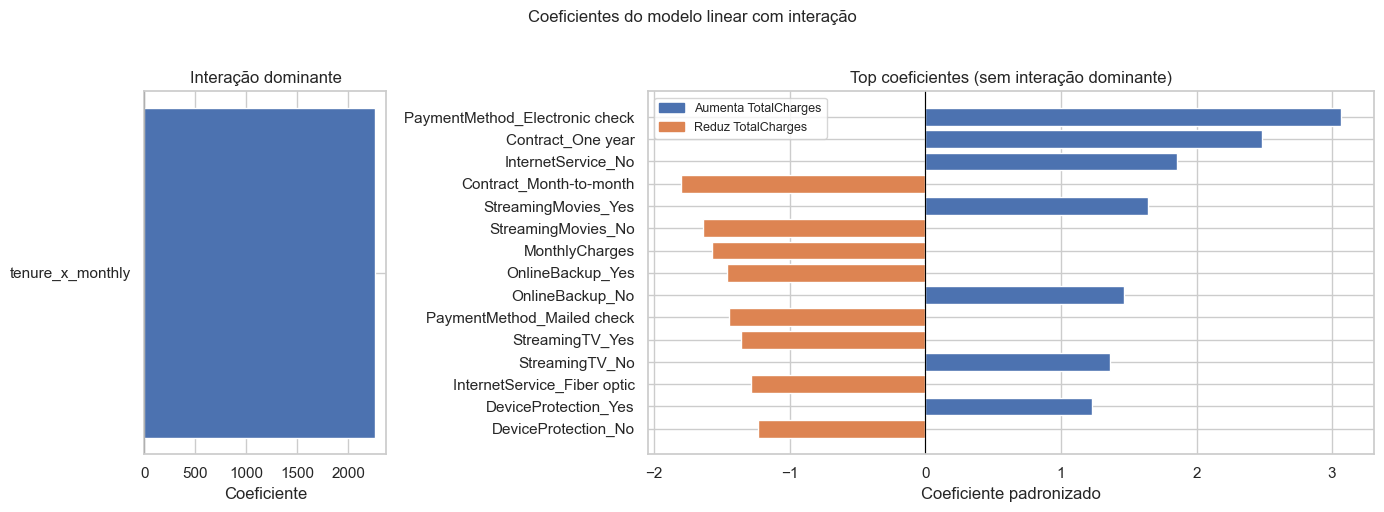

In [13]:
# ── Gráfico 3: Coeficientes do modelo com interação ───────────────────────────

pipe_inter.fit(X_inter_train, y_train)

ohe_features = pipe_inter.named_steps['prep'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(CAT_COLS).tolist()

all_features = NUM_COLS_INTER + ohe_features
coefs = pipe_inter.named_steps['reg'].coef_

coef_df = pd.DataFrame({
    'feature': all_features,
    'coef': coefs
})

# separa interação para não destruir a escala visual
interaction_row = coef_df[coef_df['feature'] == 'tenure_x_monthly']
coef_df_plot = coef_df[coef_df['feature'] != 'tenure_x_monthly']

coef_df_plot = (
    coef_df_plot
    .assign(abs_coef=lambda d: d['coef'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [1, 3]}
)

# ── Painel esquerda: interação dominante ──────────────────────────────────────
ax = axes[0]

interaction_coef = interaction_row['coef'].iloc[0]
interaction_color = '#4C72B0' if interaction_coef >= 0 else '#DD8452'

ax.barh(
    ['tenure_x_monthly'],
    [interaction_coef],
    color=interaction_color
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Interação dominante')
ax.set_xlabel('Coeficiente')

# ── Painel direita: demais coeficientes ───────────────────────────────────────
ax = axes[1]

colors = [
    '#4C72B0' if c >= 0 else '#DD8452'
    for c in coef_df_plot['coef']
]

ax.barh(
    coef_df_plot['feature'][::-1],
    coef_df_plot['coef'][::-1],
    color=colors[::-1],
    edgecolor='white'
)

ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Coeficiente padronizado')
ax.set_title('Top coeficientes (sem interação dominante)')

import matplotlib.patches as mpatches

ax.legend(handles=[
    mpatches.Patch(color='#4C72B0', label='Aumenta TotalCharges'),
    mpatches.Patch(color='#DD8452', label='Reduz TotalCharges')
], fontsize=9)

plt.suptitle(
    'Coeficientes do modelo linear com interação',
    y=1.02,
    fontsize=12
)

plt.tight_layout()
plt.show()

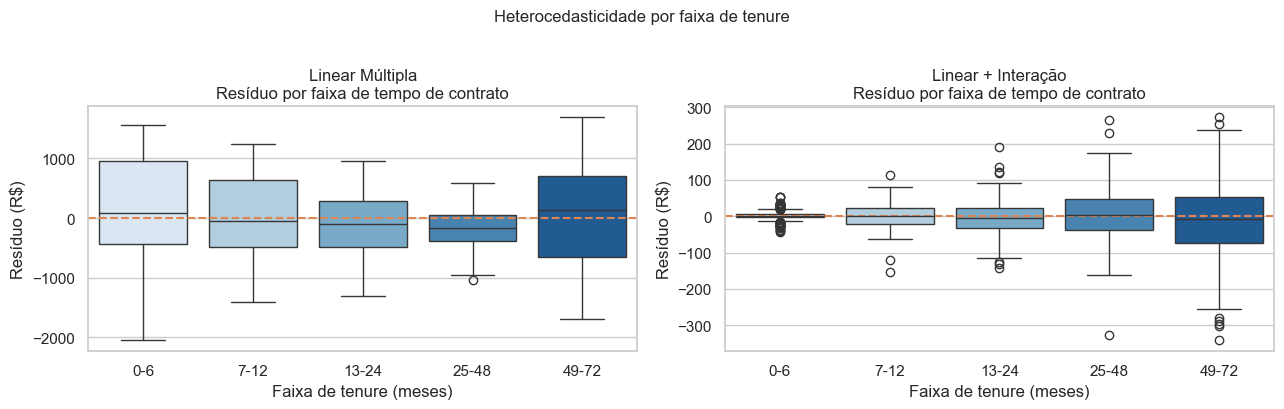

Desvio padrão dos resíduos por faixa de tenure (Modelo 1 vs. Modelo 2):


,DP Resíduo — Linear,DP Resíduo — Interação
tenure_band,,
0-6,794.48,12.87
7-12,653.14,34.61
13-24,510.33,48.36
25-48,304.71,66.71
49-72,855.82,98.72


In [13]:
# ── Gráfico 4: Resíduos por faixa de tenure (verifica heterocedasticidade) ────
# Se os resíduos do Modelo 1 crescem junto com tenure, há heterocedasticidade.
# Isso motivaria o uso da interação (Modelo 2).

tenure_test = X_test['tenure'].values
tenure_bins = pd.cut(tenure_test, bins=[0, 6, 12, 24, 48, 72],
                     labels=['0-6', '7-12', '13-24', '25-48', '49-72'],
                     include_lowest=True)

diag_df = pd.DataFrame({
    'tenure_band'   : tenure_bins,
    'resid_linear'  : res_linear['residuals'],
    'resid_inter'   : res_inter['residuals']
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, titulo in zip(
    axes,
    ['resid_linear', 'resid_inter'],
    ['Linear Múltipla', 'Linear + Interação']
):
    sns.boxplot(
        data=diag_df, x='tenure_band', y=col, ax=ax,
        palette='Blues', order=['0-6', '7-12', '13-24', '25-48', '49-72']
    )
    ax.axhline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Faixa de tenure (meses)')
    ax.set_ylabel('Resíduo (R$)')
    ax.set_title(f'{titulo}\nResíduo por faixa de tempo de contrato')

plt.suptitle('Heterocedasticidade por faixa de tenure', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Desvio dos resíduos por faixa (se sobe com tenure → heterocedasticidade)
print('Desvio padrão dos resíduos por faixa de tenure (Modelo 1 vs. Modelo 2):')
std_by_band = diag_df.groupby('tenure_band', observed=True)[['resid_linear', 'resid_inter']].std().round(2)
std_by_band.columns = ['DP Resíduo — Linear', 'DP Resíduo — Interação']
display(std_by_band)

### Conclusão da Questão 3

O subproblema de regressão definido para esta etapa se mostrou coerente tanto do ponto de vista técnico quanto de negócio. Mesmo que a base Telco tenha sido originalmente criada para classificação de churn, a previsão de `TotalCharges` permitiu explorar um cenário realista de estimativa de valor de cliente, diretamente relacionado ao conceito de LTV (*Lifetime Value*)¹.

Os resultados mostraram uma diferença significativa entre os dois modelos testados. A Regressão Linear Múltipla tradicional apresentou desempenho razoável, conseguindo explicar boa parte da variabilidade da variável alvo. No entanto, o modelo com interação entre `tenure` e `MonthlyCharges` obteve resultados muito superiores, alcançando valores de R² próximos de 0.96 e reduzindo consideravelmente os erros médios de previsão.

Esse ganho faz sentido quando observado o comportamento estrutural da base. O valor de `TotalCharges` depende fortemente do produto entre mensalidade e tempo de permanência do cliente  `(MonthlyCharges * tenure)`.  
Como a regressão linear simples trabalha de forma aditiva, ela não consegue representar completamente essa relação. Ao incluir explicitamente o termo de interação, o segundo modelo passa a capturar melhor a dinâmica real dos dados.

A análise dos resíduos também ajudou a validar essa interpretação. No primeiro modelo, foi possível observar aumento da dispersão dos erros conforme os valores previstos cresciam, caracterizando o que chamamos de heterocedasticidade². Esse comportamento ficou mais controlado no modelo com interação, indicando que parte importante da estrutura dos dados passou a ser explicada corretamente.

Também foram observados sinais de não linearidade residual e presença de alguns outliers. Grande parte desses casos está associada a clientes recém-chegados (`tenure = 0`) que já possuem cobrança registrada, além de clientes com mudanças de plano ou cobranças atípicas. Apesar disso, a quantidade de outliers não foi suficiente para comprometer a estabilidade geral do modelo.

Do ponto de vista de aplicação prática, o modelo com interação se mostrou o mais adequado. Mesmo apresentando um erro médio de algumas centenas de reais, o nível de precisão obtido é suficiente para apoiar decisões de negócio relacionadas à priorização de campanhas de retenção e segmentação de clientes por valor projetado. Além disso, os coeficientes do modelo permanecem interpretáveis, reforçando que o principal fator associado ao valor acumulado do cliente é justamente a combinação entre mensalidade e tempo de permanência no serviço.

###### ¹ métrica que estima o total de receita ou lucro líquido que um cliente gera para uma empresa durante todo o seu relacionamento com a empresa.
###### 2 fenômeno em que a variância dos erros de um modelo de regressão não é constante ao longo dos valores previstos, o que pode indicar que o modelo não está capturando completamente a estrutura dos dados.
